# 5D Cournot deterministic/stochastic analysis

This notebook uses a residual MLP and reproducibly reselects a random subset of tangent coordinates at every DTB iteration. It advances the accumulated particle map directly and supports deterministic/Euler or stochastic probability-flow/Euler--Maruyama comparisons.



In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt

# Locate this project for numerical output.
repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / 'pyproject.toml').is_file() and (path / 'src' / 'dtb_game').is_dir()),
    None,
)
if repo_root is None:
    raise FileNotFoundError('Open this notebook from the project checkout.')

from dtb_game import (ConstantDiffusion, CournotGame, ExperimentConfig, run_experiment, run_step_size_sweep)
from dtb_game.plotting import (plot_cloud_snapshots, plot_configuration_diagnostics, plot_diagnostics, plot_final_time_rms_sweep, plot_relative_projection_sweep, plot_step_size_sweep, plot_stochastic_diagnostics)

package_dir = repo_root


## Game, diffusion, and numerical setup

For $s_i=\sum_{j\ne i}x_j$, the drift is

$$
b_i(x)=2b\left(\max\{\mu s_i(1-s_i),0\}-x_i\right),
\qquad b=2,\quad \mu=\frac74.
$$

When `RUN_STOCHASTIC=True`, the SDE adds $\Sigma\,dW_t$ with $\Sigma=0.1I_5$. The probability-flow DTB target includes its score correction, and the reference automatically becomes Euler--Maruyama. The remaining settings preserve the current comparison.


In [2]:
RUN_STOCHASTIC = True
RUN_STEP_SIZE_SWEEP = False
SWEEP_STEP_SIZES = (0.02, 0.01, 0.005, 0.0025)
NOISE_AMPLITUDE = 0.1

game = CournotGame(dim=5, b=2.0, mu=7/4)
diffusion = (
    ConstantDiffusion.isotropic(game.dim, amplitude=NOISE_AMPLITUDE)
    if RUN_STOCHASTIC
    else None
)
mode = 'stochastic' if RUN_STOCHASTIC else 'deterministic'

config = ExperimentConfig(
    dynamics=mode,
    run_reference=True,
    particle_count=5000,
    initial_law='smoothed_uniform',
    smoothing_std=0.02,
    step_size=0.005,
    final_time=2.0,
    snapshot_times=(0.0, 0.5, 1.0, 2.0),
    width=16,
    depth=2,
    activation='tanh',
    model_kind='residual_mlp',
    basis_size=64,
    subset_tangent_selection='resample_each_step',
    svd_rtol=1e-6,
    jacobian_chunk=256,
    score_chunk=32,
    seed=0,
    dtype='float64',
    device='auto',
    progress_reports=5,
    output_dir=package_dir / 'results' / f'cournot_5d_{mode}',
)


## Complete run or step-size sweep

With `RUN_STEP_SIZE_SWEEP=False`, this performs one configured run. Set it to `True` to run every value in `SWEEP_STEP_SIZES`. Every run resets the same particle seed, residual-MLP initialization, and tangent-subset generator. Within each run, a fresh subset is selected at every iteration, matching the deterministic comparison notebook.


In [3]:
sweep_result = None
if RUN_STEP_SIZE_SWEEP:
    sweep_result = run_step_size_sweep(
        game,
        SWEEP_STEP_SIZES,
        config,
        diffusion=diffusion,
    )
    result = sweep_result.runs[
        config.step_size if config.step_size in sweep_result.runs else min(SWEEP_STEP_SIZES)
    ]
else:
    result = run_experiment(game, config, diffusion=diffusion)

result.summary()


DTB run: game=cournot_5d_b2_mu7_4, dynamics=stochastic, reference=euler_maruyama, device=cuda, dtype=torch.float64, particles=5000, steps=400, parameters=453, model=residual_mlp, subset_size=64, subset_selection=resample_each_step, tangent_inputs=current_particles, reference_step=0.005


/storage/project/r-hz25-0/msun351/msun351/conda-envs/dtb-blackwell/lib/python3.11/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


 20.0% | step 80/400 | t=0.4 | residual=9.2923e-01 | score=1.902e+02 | elapsed=1.8 min | ETA=7.2 min
 40.0% | step 160/400 | t=0.8 | residual=8.6150e-01 | score=1.770e+02 | elapsed=3.5 min | ETA=5.3 min
 60.0% | step 240/400 | t=1.2 | residual=8.4455e-01 | score=1.738e+02 | elapsed=5.2 min | ETA=3.5 min
 80.0% | step 320/400 | t=1.6 | residual=8.3282e-01 | score=1.720e+02 | elapsed=7.0 min | ETA=1.7 min
100.0% | step 400/400 | t=2 | residual=8.3556e-01 | score=1.729e+02 | elapsed=8.7 min | ETA=0.0 min
Complete in 8.7 min | DTB/euler_maruyama mean distance=8.1696e-03 | paired RMS=2.6206e-01


{'game': 'cournot_5d_b2_mu7_4',
 'dynamics': 'stochastic',
 'reference_method': 'euler_maruyama',
 'model_kind': 'residual_mlp',
 'subset_tangent_selection': 'resample_each_step',
 'tangent_input_mode': 'current_particles',
 'particle_count': 5000,
 'dimension': 5,
 'step_count': 400,
 'final_time': 2.0,
 'elapsed_seconds': 520.4429612071253,
 'final_mean_distance': 0.008169624525255161,
 'final_paired_rms': 0.2620649208565152,
 'final_projection_error': 0.8359797606957289,
 'final_relative_projection_error': 0.997385927134757,
 'final_alpha_norm': 34.524809564107315,
 'final_projection_condition': 3543.682333420081,
 'final_projection_rank': 64,
 'final_trajectory_rms_error': 0.2620649208565152,
 'final_physical_network_gap': None,
 'final_network_trajectory_rms_error': None,
 'final_score_rms': 173.0317157705469,
 'maximum_condition_number': 70385.24651334566,
 'output_dir': '/storage/home/hcoda1/7/msun351/DTB_Ver3/results/cournot_5d_stochastic'}

## Particle clouds and diagnostics

The selected `result` configuration gets a four-panel diagnostic figure: trajectory RMS, relative projection error, coefficient norm, and Jacobian condition. A sweep also plots its last-step relative projection error against step size.


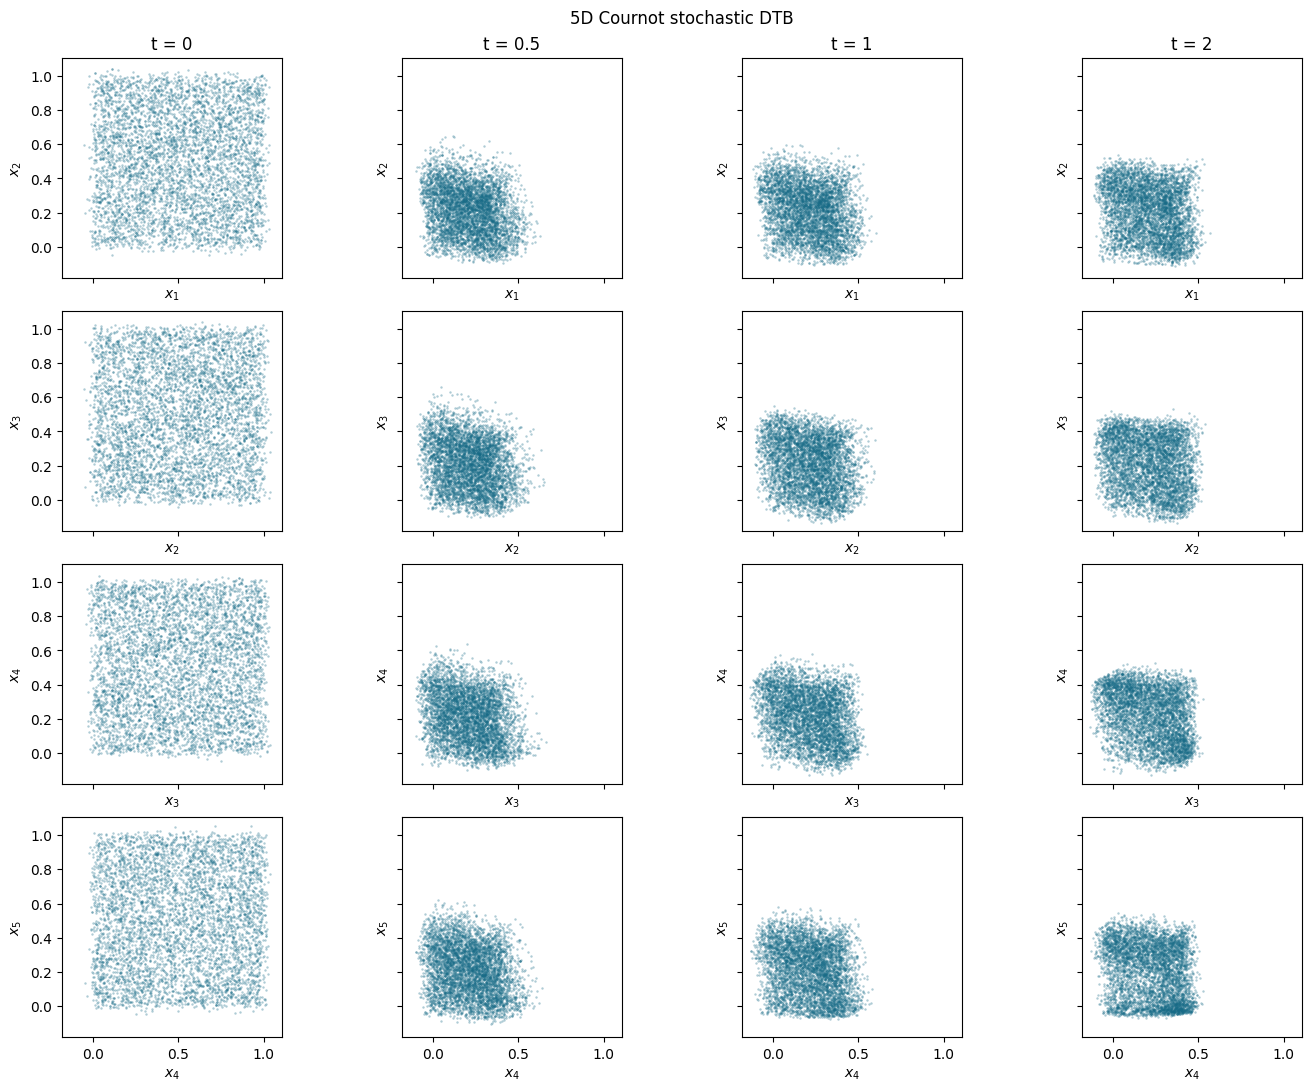

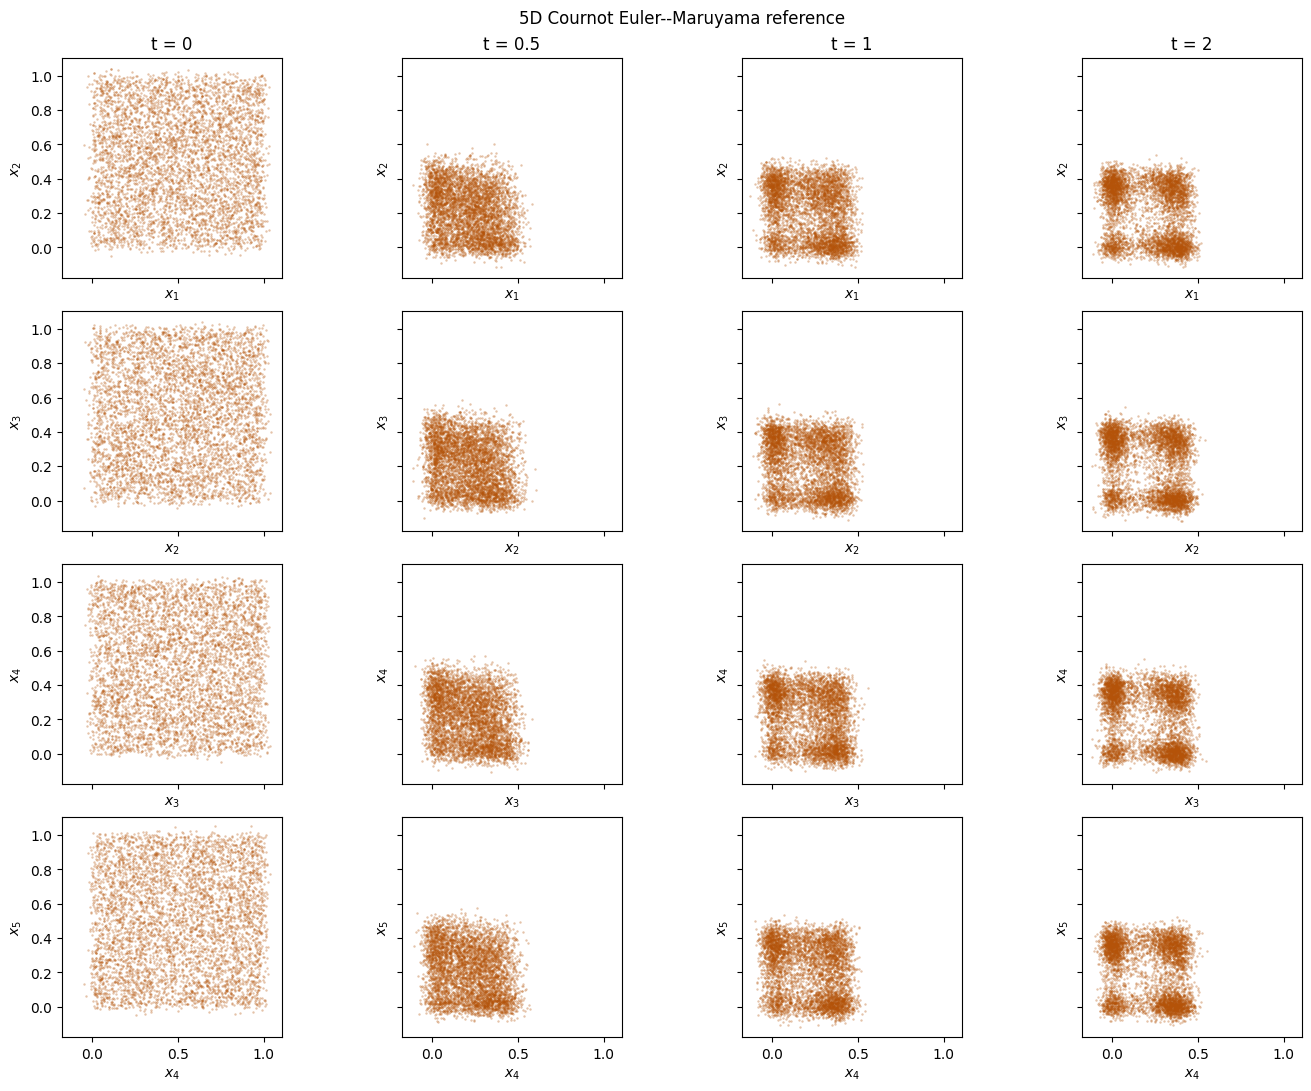

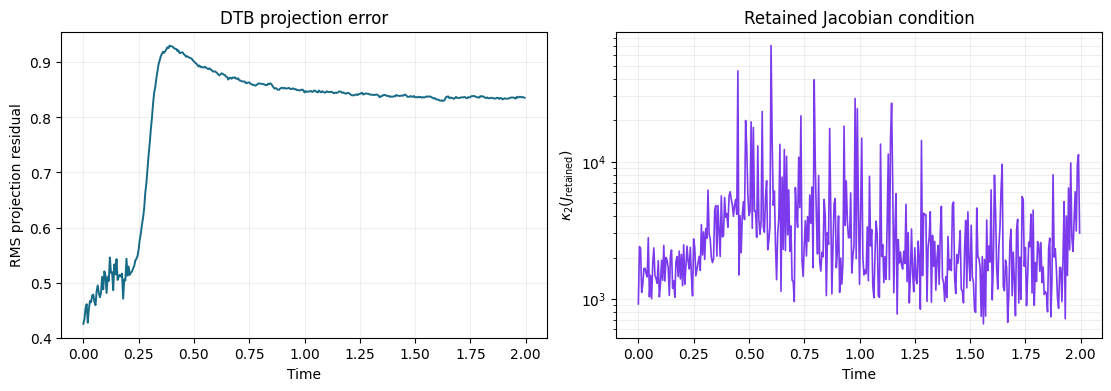

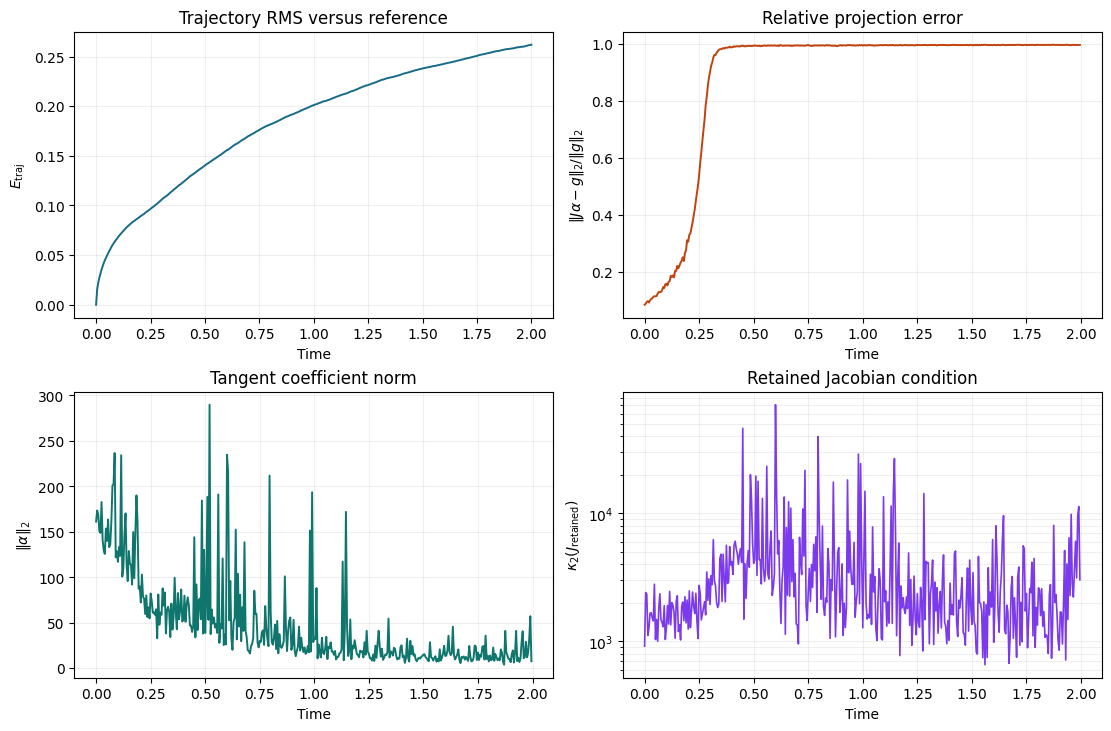

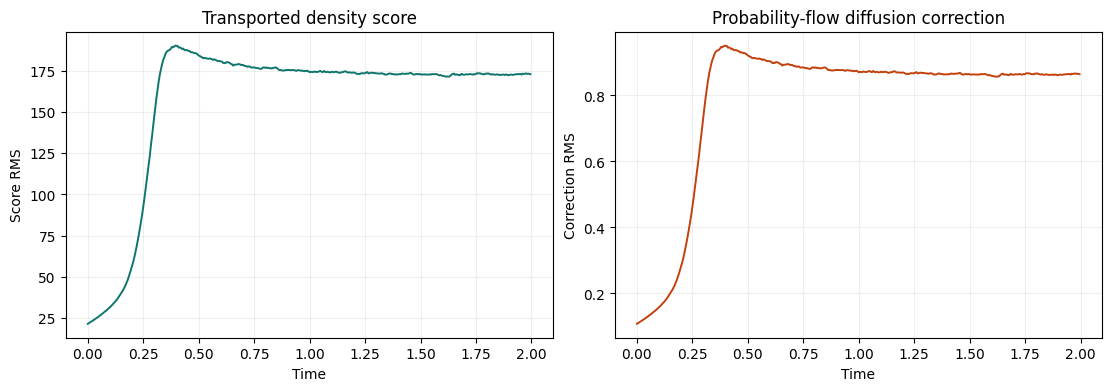

In [4]:
pairs = ((1, 2), (2, 3), (3, 4), (4, 5))

plot_cloud_snapshots(
    result.dtb_snapshots,
    coordinate_pairs=pairs,
    title=f'5D Cournot {result.dynamics} DTB',
    color='#176b87',
    output_path=result.output_dir / 'dtb_point_clouds.png',
)
plt.show()

if result.reference_snapshots:
    reference_label = (
        'Euler--Maruyama' if result.reference_method == 'euler_maruyama' else 'Euler'
    )
    plot_cloud_snapshots(
        result.reference_snapshots,
        coordinate_pairs=pairs,
        title=f'5D Cournot {reference_label} reference',
        color='#b45309',
        output_path=result.output_dir / 'reference_point_clouds.png',
    )
    plt.show()

plot_diagnostics(
    result.projection_times,
    result.projection_error,
    result.jacobian_condition,
    output_path=result.output_dir / 'dtb_diagnostics.png',
)
plt.show()

plot_configuration_diagnostics(
    result.times,
    result.trajectory_rms_error,
    result.projection_times,
    result.relative_projection_error,
    result.alpha_norm,
    result.jacobian_condition,
    output_path=result.output_dir / 'configuration_diagnostics.png',
)
plt.show()

if result.dynamics == 'stochastic':
    plot_stochastic_diagnostics(
        result.projection_times,
        result.score_rms,
        result.diffusion_correction_rms,
        output_path=result.output_dir / 'stochastic_diagnostics.png',
    )
    plt.show()

if sweep_result is not None:
    metric_label = (
        'Sliced 2-Wasserstein distance'
        if sweep_result.metric_name == 'sliced_wasserstein_2'
        else 'Paired-particle RMS'
    )
    plot_step_size_sweep(
        sweep_result.records,
        metric_label=metric_label,
        output_path=sweep_result.output_dir / 'step_size_sweep.png',
    )
    plt.show()

    print(f'Final-time RMS error at T={config.final_time:g}:')
    for step_size, rms_error in zip(
        sweep_result.step_sizes,
        sweep_result.final_time_rms_error,
    ):
        print(f'  h={step_size:g}: {rms_error:.8e}')
    plot_final_time_rms_sweep(
        sweep_result.step_sizes,
        sweep_result.final_time_rms_error,
        final_time=config.final_time,
        output_path=sweep_result.output_dir / 'final_time_rms_vs_step_size.png',
    )
    plt.show()

    print('Last-step relative projection error:')
    for step_size, relative_error in zip(
        sweep_result.step_sizes,
        sweep_result.final_relative_projection_error,
    ):
        print(f'  h={step_size:g}: {relative_error:.8e}')
    plot_relative_projection_sweep(
        sweep_result.step_sizes,
        sweep_result.final_relative_projection_error,
        output_path=(
            sweep_result.output_dir / 'relative_projection_error_vs_step_size.png'
        ),
    )
    plt.show()


## Package the saved run or complete sweep


In [5]:
import shutil

archive_folder = sweep_result.output_dir if sweep_result is not None else result.output_dir
archive = shutil.make_archive(
    str(archive_folder),
    'zip',
    root_dir=archive_folder.parent,
    base_dir=archive_folder.name,
)
print('Saved result archive:', archive)

try:
    from google.colab import files
except ImportError:
    pass
else:
    files.download(archive)


Saved result archive: /storage/home/hcoda1/7/msun351/DTB_Ver3/results/cournot_5d_stochastic.zip
